# 01 — Data Cleaning

**Phase 1 of the customer-segmentation pipeline.** Load the raw *Online Retail II*
transactions, profile the data-quality quirks, apply the cleaning rules from
`planning/docs/16`, and emit a clean transaction table.

The cleaning *logic* lives in `src/data_prep.py` (unit-tested). This notebook **narrates and
runs** it on the real data, and keeps a visible record of the result.

**Pipeline:** Load & Merge → Drop Invalid Records → Resolve Non-Purchases → Clean Dataset.

In [1]:
# Setup: make `from src import ...` work whether run from notebooks/ or the project root.
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import data_prep, utils

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")

## 1. Load the raw data

Both year-sheets, concatenated into one transaction table — one row per invoice line (doc 03).

In [2]:
raw = data_prep.load_raw()
print(f"rows: {len(raw):,}    columns: {raw.shape[1]}")
raw.head()

rows: 1,067,371    columns: 9


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,SourceSheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,Year 2009-2010


In [3]:
raw["SourceSheet"].value_counts()

SourceSheet
Year 2010-2011    541910
Year 2009-2010    525461
Name: count, dtype: int64[pyarrow]

**Data-contract check** — these must match the documented facts (doc 03).

In [4]:
print(f"unique customers : {raw['Customer ID'].nunique():,}   (doc 03: 5,942)")
print(f"countries        : {raw['Country'].nunique()}   (doc 03: 43)")
print(f"date range       : {raw['InvoiceDate'].min()}  ->  {raw['InvoiceDate'].max()}")

unique customers : 5,942   (doc 03: 5,942)
countries        : 43   (doc 03: 43)
date range       : 2009-12-01 07:45:00  ->  2011-12-09 12:50:00


## 2. Raw-data quality — the quirks that justify cleaning

We *show* the problems before fixing them (doc 16): missing IDs, cancellations, returns,
bad prices, and non-product codes.

In [5]:
n = len(raw)
quirks = {
    "missing Customer ID": int(raw["Customer ID"].isna().sum()),
    "cancellations (C)":   int(raw["Invoice"].astype(str).str.startswith("C").sum()),
    "negative quantity":   int((raw["Quantity"] < 0).sum()),
    "price <= 0":          int((raw["Price"] <= 0).sum()),
    "non-product code":    int(raw["StockCode"].map(utils.is_non_product).sum()),
}
for k, v in quirks.items():
    print(f"{k:22}: {v:>9,}  ({v / n:.1%})")

missing Customer ID   :   243,007  (22.8%)
cancellations (C)     :    19,494  (1.8%)
negative quantity     :    22,950  (2.2%)
price <= 0            :     6,207  (0.6%)
non-product code      :     5,930  (0.6%)


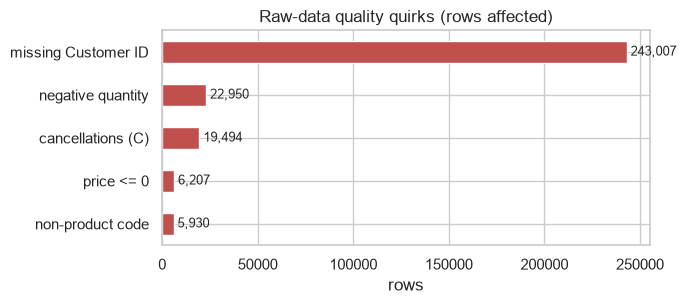

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
s = pd.Series(quirks).sort_values()
s.plot.barh(ax=ax, color="#c0504d")
ax.set_title("Raw-data quality quirks (rows affected)")
ax.set_xlabel("rows")
for i, v in enumerate(s):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(utils.REPORTS_FIGURES / "01_raw_quirks.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Apply the cleaning pipeline

`build_clean_table` chains the steps and returns a full reconciliation (doc 16).

In [7]:
purchases, non_purchases, recon = data_prep.build_clean_table(raw)

print(f"clean purchase rows       : {len(purchases):,}")
print(f"unique customers remaining: {purchases['Customer ID'].nunique():,}")
print(f"non-purchase rows captured: {len(non_purchases):,}")

clean purchase rows       : 790,704
unique customers remaining: 5,852
non-purchase rows captured: 17,878


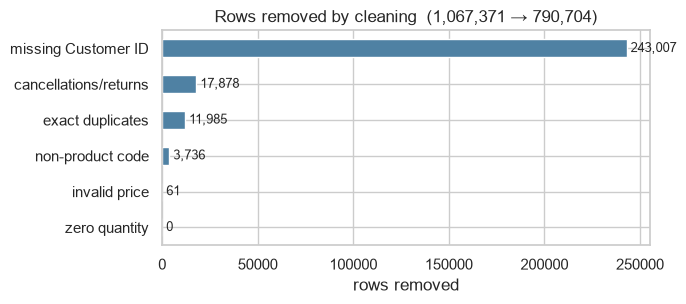

In [8]:
# How many rows each cleaning rule removed (the reconciliation, as a chart).
removed = {
    "missing Customer ID":   recon["detail_invalid"]["missing_customer_id"],
    "exact duplicates":      recon["detail_invalid"]["exact_duplicates"],
    "non-product code":      recon["detail_invalid"]["non_product_stockcode"],
    "invalid price":         recon["detail_invalid"]["invalid_price"],
    "zero quantity":         recon["detail_invalid"]["zero_quantity"],
    "cancellations/returns": recon["detail_non_purchases"]["non_purchases_removed"],
}
fig, ax = plt.subplots(figsize=(7, 3.2))
s = pd.Series(removed).sort_values()
s.plot.barh(ax=ax, color="#4f81a3")
ax.set_title(f"Rows removed by cleaning  ({recon['raw_rows']:,} → {recon['clean_rows']:,})")
ax.set_xlabel("rows removed")
for i, v in enumerate(s):
    ax.text(v, i, f" {v:,}", va="center", fontsize=9)
fig.tight_layout()
fig.savefig(utils.REPORTS_FIGURES / "01_cleaning_reconciliation.png", dpi=150, bbox_inches="tight")
plt.show()

**Lossless check** — every raw row is accounted for: `clean + invalid-dropped + non-purchases == raw`.

In [9]:
invalid_dropped = recon["raw_rows"] - recon["after_drop_invalid"]
assert recon["raw_rows"] == recon["clean_rows"] + invalid_dropped + recon["non_purchases_rows"]
print(f"{recon['raw_rows']:,} = {recon['clean_rows']:,} (clean) + "
      f"{invalid_dropped:,} (invalid) + {recon['non_purchases_rows']:,} (non-purchases)  ✓")

1,067,371 = 790,704 (clean) + 258,789 (invalid) + 17,878 (non-purchases)  ✓


## 4. Save the clean table

Written to `data/processed/` as **Parquet** (typed, fast to reload — the xlsx read is slow).
Git-ignored. The `non_purchases` table is kept for the per-customer return-rate (doc 16).

In [10]:
utils.DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
clean_path = utils.DATA_PROCESSED / "clean_transactions.parquet"
purchases.to_parquet(clean_path, index=False)
non_purchases.to_parquet(utils.DATA_PROCESSED / "non_purchases.parquet", index=False)
print(f"saved {clean_path.name}  ({len(purchases):,} rows)")
print(f"saved non_purchases.parquet  ({len(non_purchases):,} rows)")

saved clean_transactions.parquet  (790,704 rows)
saved non_purchases.parquet  (17,878 rows)


---
**Result:** ~790k clean purchase rows, ~5,850 customers, every raw row reconciled.

**Next:** `02_eda` (behavioural EDA on the clean data) and `03_features`
(RFM + the three feature lanes — core / CLV inputs / supporting).